In [6]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv('house.csv')

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [16]:
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [31]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [10]:
X = df[['Square_Footage','Num_Bedrooms','Num_Bathrooms','Year_Built','Lot_Size','Garage_Size','Neighborhood_Quality']]
y = df[['House_Price']]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2)

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print("기울기: " , lr.coef_)
print("절편: " , lr.intercept_)

기울기:  [[  199.73792206 10317.97753833  8593.13311085   995.94291259
  14943.08562408  5502.14450808   186.96770621]]
절편:  [-2017791.64035644]


In [27]:
train_score =lr.score(X_train,y_train)
test_score = lr.score(X_test, y_test)
print(train_score, test_score)

0.9985275121686615 0.9984379524655884


In [20]:
y_predict = lr.predict(X_test)
y_predict

array([[ 661098.80502073],
       [ 835168.40580398],
       [ 273505.06416564],
       [ 637602.26124049],
       [ 687695.96842356],
       [ 572882.04107534],
       [ 476790.16507676],
       [ 280076.71003253],
       [ 836161.03386625],
       [ 425075.82799406],
       [ 620685.07800725],
       [ 503439.57388481],
       [ 259663.76975567],
       [ 548699.15627045],
       [ 340546.14214567],
       [ 281101.41447425],
       [ 146692.18517631],
       [ 510933.50388599],
       [ 313174.88743284],
       [ 459947.67555619],
       [ 251322.72699822],
       [ 895684.87487453],
       [ 542176.01043933],
       [ 597363.20347496],
       [ 856410.09524572],
       [ 134326.33440249],
       [ 678114.05321091],
       [ 820374.46297704],
       [ 980439.25427682],
       [ 220218.31671286],
       [ 316542.1062788 ],
       [ 926895.67112052],
       [ 487055.51109319],
       [1031366.08266812],
       [ 505546.05885856],
       [ 870271.27513391],
       [ 930560.69953339],
 

In [28]:
import matplotlib.pyplot as plt

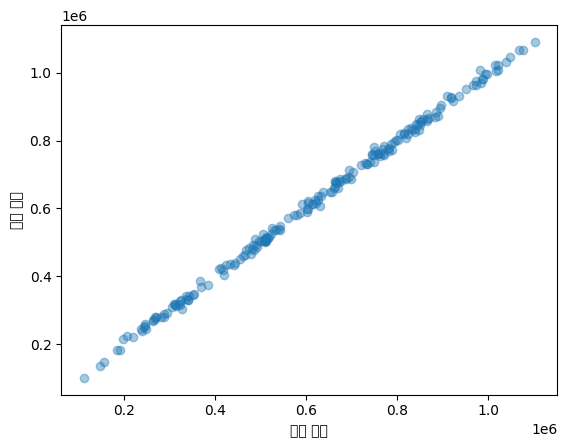

In [34]:
plt.scatter(y_test, y_predict, alpha=0.4)
plt.xlabel("실제 가격")
plt.ylabel("예측 가격")
plt.show()

In [36]:
from xgboost.sklearn import XGBClassifier, XGBRegressor

In [54]:
reg = XGBRegressor(objective ='reg:linear', learning_rate = 0.2, max_depth = 5, alpha = 10, n_estimators = 10, sub_sample=0.5)

In [55]:
reg.fit(X_train,y_train)

XGBRegressor(alpha=10, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10,
             n_jobs=None, ...)

In [56]:
xgb_pred= reg.predict(X_test)
xgb_pred

array([652770.4 , 791734.06, 295936.47, 641121.06, 715866.94, 567723.94,
       465600.44, 292054.28, 752590.3 , 416040.7 , 637110.7 , 525162.75,
       314570.75, 558715.56, 369158.47, 333925.34, 245121.73, 543755.44,
       397629.97, 460830.5 , 317255.28, 841225.8 , 551237.75, 607807.  ,
       810329.3 , 226570.05, 662627.1 , 797883.75, 919058.25, 313373.1 ,
       346537.34, 900824.94, 508049.16, 976420.3 , 524841.94, 861237.56,
       903544.  , 932194.44, 804229.94, 637192.3 , 413360.53, 474085.34,
       847462.4 , 442341.25, 667657.  , 845508.56, 654568.44, 833805.5 ,
       288833.12, 314082.25, 585047.75, 508060.56, 991321.6 , 984748.7 ,
       370018.  , 430574.88, 666018.1 , 351976.38, 320487.22, 509454.78,
       809932.06, 526435.  , 380375.97, 476528.38, 532594.6 , 967781.8 ,
       783506.44, 825321.44, 446996.06, 823363.4 , 834987.25, 359140.34,
       379009.9 , 731869.5 , 822535.6 , 805709.1 , 477927.62, 609067.3 ,
       749583.5 , 718132.5 , 855481.3 , 626646.75, 

In [58]:
xgb_trainscore = reg.score(X_train,y_train)
xgb_testscore = reg.score(X_test,y_test)
print(xgb_trainscore, xgb_testscore)

0.9816374182701111 0.9752541780471802


In [2]:
from lightgbm import LGBMRegressor

In [17]:
gbm = LGBMRegressor(learning_rate=0.1, max_depth=1, objective='regression', metric ='mse', is_training_metric = True, num_leaves=31, feature_fraction=0.9)

In [18]:
gbm.fit(X_train,y_train)

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 608
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 7
[LightGBM] [Info] Start training from score 621598.418936
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

LGBMRegressor(feature_fraction=0.9, is_training_metric=True, max_depth=1,
              metric='mse', objective='regression')

In [19]:
train_score = gbm.score(X_train, y_train)
test_score = gbm.score(X_test, y_test)
print(train_score)
print(test_score)

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
0.9921601098204743
0.9903606634248527
